1. Для придания смысла кластерам выведите примеры точек выборки для каждого кластера. Сделайте вывод, чем они отличаются.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Загрузка и предобработка
df = pd.read_csv('mall_customers_clustering.csv', index_col=0)
x = df.drop(["CustomerID"], axis=1)
X = pd.get_dummies(x)

# Нормализация
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# KMeans с оптимальным числом кластеров
kmeans = KMeans(n_clusters=4, random_state=42).fit(X_scaled)
df['Cluster'] = kmeans.labels_

# Примеры точек из каждого кластера
for cl in range(4):
    print(f"\nКластер {cl}")
    sample = df[df['Cluster'] == cl].head(5)
    print(sample[['Age', 'Income', 'Score', 'Genre']])

# Средние значения для интерпретации
print("\nСредние характеристики кластеров:")
print(df.groupby('Cluster')[['Age', 'Income', 'Score']].mean())
print(df.groupby('Cluster')['Genre'].value_counts(normalize=True))


Кластер 0
    Age  Income  Score Genre
8    64   19000   0.03  Male
10   67   19000   0.14  Male
14   37   20000   0.13  Male
18   52   23000   0.29  Male
20   35   24000   0.35  Male

Кластер 1
    Age  Income  Score   Genre
3    23   16000   0.77  Female
5    22   17000   0.76  Female
7    23   18000   0.94  Female
9    30   19000   0.72  Female
11   35   19000   0.99  Female

Кластер 2
    Age  Income  Score   Genre
2    20   16000   0.06  Female
4    31   17000   0.40  Female
6    35   18000   0.06  Female
12   58   20000   0.15  Female
16   35   21000   0.35  Female

Кластер 3
    Age  Income  Score Genre
0    19   15000   0.39  Male
1    21   15000   0.81  Male
15   22   20000   0.79  Male
17   20   21000   0.66  Male
21   25   24000   0.73  Male

Средние характеристики кластеров:
               Age        Income     Score
Cluster                                   
0        49.437500  62416.666667  0.292083
1        28.392857  60428.571429  0.681786
2        47.803571  58071.428

2. Используйте для визуализации результатов кластеризации другие пары признаков. Сделайте вывод о зависимости кластеризации от признаков.

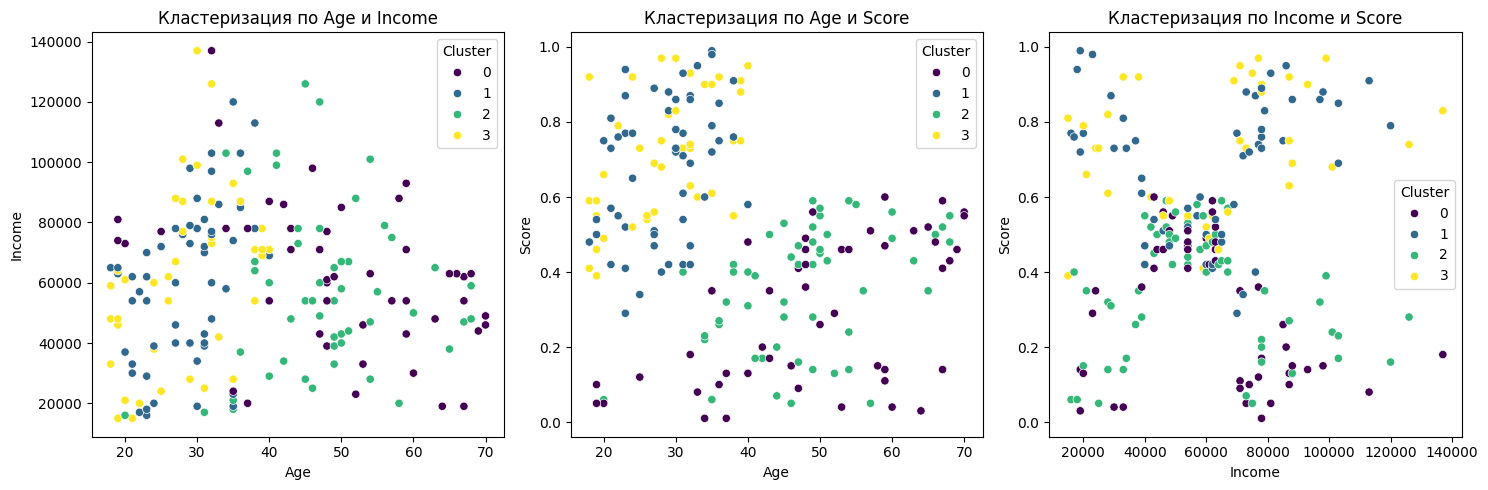

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Используем числовые признаки из df
pairs = [('Age', 'Income'), ('Age', 'Score'), ('Income', 'Score')]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (x_attr, y_attr) in enumerate(pairs):
    sns.scatterplot(data=df, x=x_attr, y=y_attr, hue='Cluster', palette='viridis', ax=axes[i])
    axes[i].set_title(f'Кластеризация по {x_attr} и {y_attr}')
plt.tight_layout()
plt.show()

3. Повторите весь анализ для другого датасета - кластеризации кредитных карт.

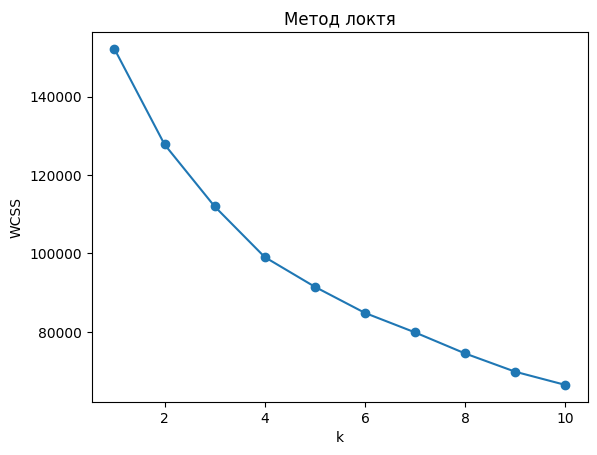

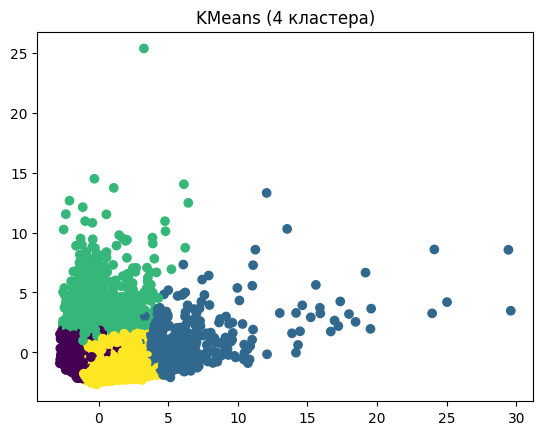

Иерархия: силуэт = 0.15978366986218748
DBSCAN: кластеров = 36, шум = 6624


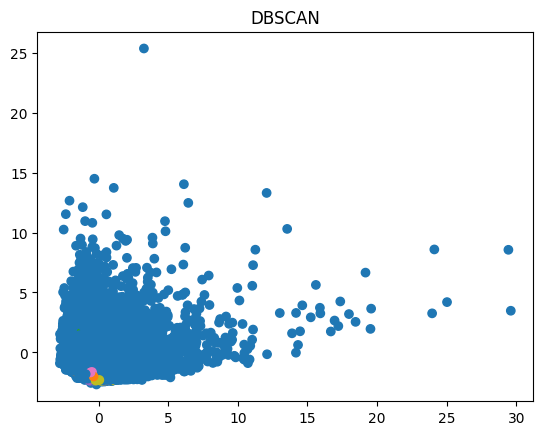

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA

# 1. Загрузка и предобработка
df = pd.read_csv('credit_card_clustering.csv', index_col=0)
df.fillna(df.median(), inplace=True)          # заполняем пропуски медианой

# 2. Нормализация
scaler = StandardScaler()
X = scaler.fit_transform(df)

# 3. Метод локтя для KMeans
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Метод локтя')
plt.xlabel('k')
plt.ylabel('WCSS')
plt.show()

# 4. KMeans с 4 кластерами
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X)

# Визуализация через PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap='viridis')
plt.title('KMeans (4 кластера)')
plt.show()

# 5. Иерархическая кластеризация
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agg = agg.fit_predict(X)
print("Иерархия: силуэт =", silhouette_score(X, labels_agg))

# 6. DBSCAN
db = DBSCAN(eps=0.5, min_samples=5)
labels_db = db.fit_predict(X)
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = list(labels_db).count(-1)
print(f"DBSCAN: кластеров = {n_clusters_db}, шум = {n_noise}")

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_db, cmap='tab10')
plt.title('DBSCAN')
plt.show()

4. В задании на иерархическую кластеризацию используйте разные методы расчета расстояния между кластерами. Сделайте выводы.

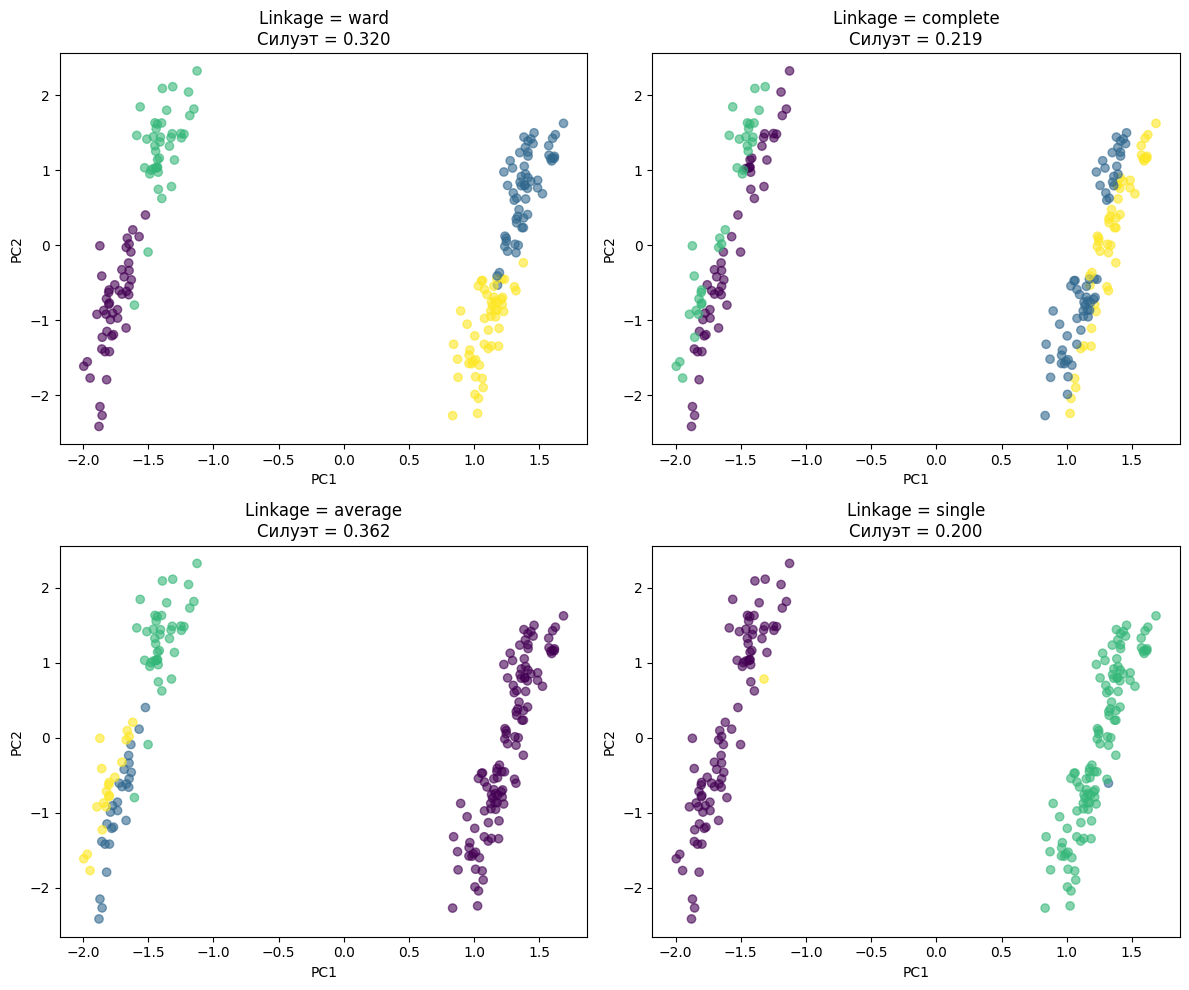

Коэффициенты силуэта для разных методов:
  ward       : 0.3202
  complete   : 0.2191
  average    : 0.3619
  single     : 0.2004


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Предполагаем, что X_scaled уже загружен и нормализован
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Разные методы linkage
linkages = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

silhouettes = {}

for i, linkage in enumerate(linkages):
    model = AgglomerativeClustering(n_clusters=4, linkage=linkage)
    labels = model.fit_predict(X_scaled)
    silhouettes[linkage] = silhouette_score(X_scaled, labels)

    axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.6)
    axes[i].set_title(f'Linkage = {linkage}\nСилуэт = {silhouettes[linkage]:.3f}')
    axes[i].set_xlabel('PC1')
    axes[i].set_ylabel('PC2')

plt.tight_layout()
plt.show()

# Вывод коэффициентов силуэта
print("Коэффициенты силуэта для разных методов:")
for k, v in silhouettes.items():
    print(f"  {k:10} : {v:.4f}")

5. В задании на DBSCAN вычислите метрику WCSS и соотнесите результаты кластеризации через DBSCAN и К-средних.

WCSS KMeans (4 кластера): 99061.94
DBSCAN: кластеров = 36, шум = 6624
WCSS DBSCAN (только кластеры): 9141.10


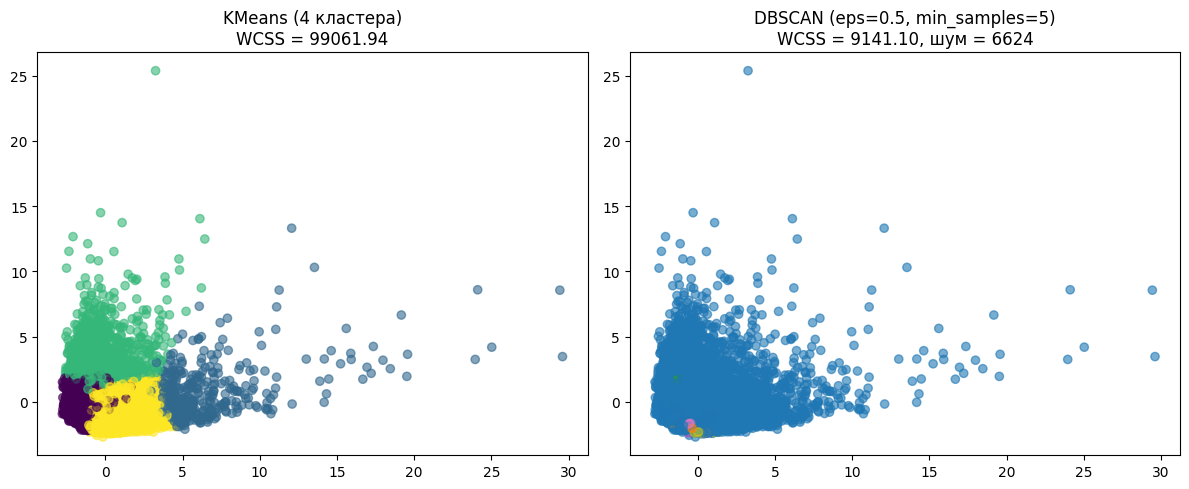

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# Загрузка и подготовка данных
df = pd.read_csv('credit_card_clustering.csv', index_col=0)
df.fillna(df.median(), inplace=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Функция для расчёта WCSS для DBSCAN
def wcss_dbscan(model, X):
    labels = model.labels_
    unique_clusters = np.unique(labels)
    unique_clusters = unique_clusters[unique_clusters != -1]  # убираем шум
    wcss = 0.0
    for cl in unique_clusters:
        points = X[labels == cl]
        if len(points) > 1:
            center = points.mean(axis=0)
            distances = np.sum((points - center) ** 2)
            wcss += distances
    return wcss

# 1. KMeans с оптимальным числом кластеров
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)
wcss_kmeans = kmeans.inertia_
print(f"WCSS KMeans (4 кластера): {wcss_kmeans:.2f}")

# 2. DBSCAN с подобранными параметрами
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = list(labels_db).count(-1)
print(f"DBSCAN: кластеров = {n_clusters_db}, шум = {n_noise}")

wcss_db = wcss_dbscan(dbscan, X_scaled)
print(f"WCSS DBSCAN (только кластеры): {wcss_db:.2f}")

# 3. Визуализация для сравнения
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, cmap='viridis', alpha=0.6)
axes[0].set_title(f'KMeans (4 кластера)\nWCSS = {wcss_kmeans:.2f}')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_db, cmap='tab10', alpha=0.6)
axes[1].set_title(f'DBSCAN (eps=0.5, min_samples=5)\nWCSS = {wcss_db:.2f}, шум = {n_noise}')

plt.tight_layout()
plt.show()

6. Постройте кривые WCSS в зависимости от параметров DBSCAN.

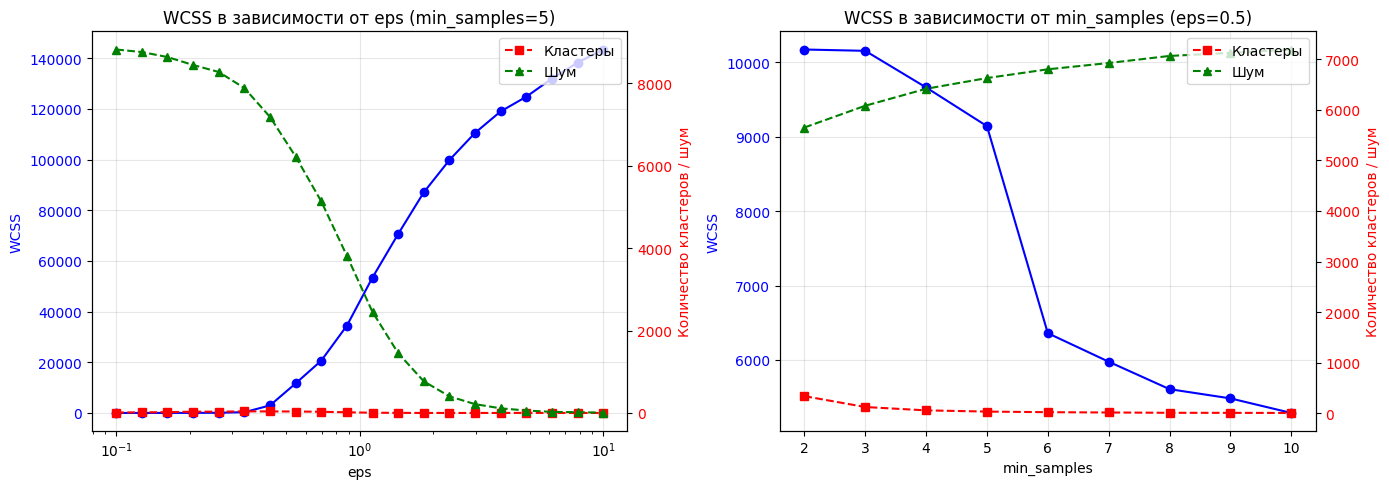

Анализ зависимости от eps:
  Рекомендуемый eps ≈ 1.129 (WCSS = 53438.1)

Анализ зависимости от min_samples:
  min_samples = 2: WCSS = 10170.5, кластеров = 341, шум = 5647
  min_samples = 3: WCSS = 10152.7, кластеров = 126, шум = 6077
  min_samples = 4: WCSS = 9660.9, кластеров = 60, шум = 6412
  min_samples = 5: WCSS = 9141.1, кластеров = 36, шум = 6624
  min_samples = 6: WCSS = 6359.9, кластеров = 24, шум = 6797
  min_samples = 7: WCSS = 5976.9, кластеров = 18, шум = 6921
  min_samples = 8: WCSS = 5608.0, кластеров = 12, шум = 7061
  min_samples = 9: WCSS = 5484.1, кластеров = 11, шум = 7121
  min_samples = 10: WCSS = 5288.4, кластеров = 9, шум = 7188


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Загрузка и подготовка данных
df = pd.read_csv('credit_card_clustering.csv', index_col=0)
df.fillna(df.median(), inplace=True)
scaler = StandardScaler()
X = scaler.fit_transform(df)

# Функция WCSS для DBSCAN (игнорируем шум)
def wcss_dbscan(labels, X):
    unique = np.unique(labels)
    unique = unique[unique != -1]
    wcss = 0.0
    for cl in unique:
        points = X[labels == cl]
        if len(points) > 1:
            center = points.mean(axis=0)
            wcss += np.sum((points - center) ** 2)
    return wcss

# 1.Зависимость WCSS от eps
eps_range = np.logspace(-1, 1, 20)
wcss_eps = []
clusters_eps = []
noise_eps = []

for eps in eps_range:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X)
    wcss = wcss_dbscan(labels, X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    wcss_eps.append(wcss)
    clusters_eps.append(n_clusters)
    noise_eps.append(n_noise)

# 2.Зависимость WCSS от min_samples
min_samples_range = range(2, 11)
wcss_min = []
clusters_min = []
noise_min = []

for ms in min_samples_range:
    db = DBSCAN(eps=0.5, min_samples=ms)
    labels = db.fit_predict(X)
    wcss = wcss_dbscan(labels, X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    wcss_min.append(wcss)
    clusters_min.append(n_clusters)
    noise_min.append(n_noise)

# Построение графиков
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График: WCSS vs eps
ax1 = axes[0]
ax1.plot(eps_range, wcss_eps, 'b-o', label='WCSS')
ax1.set_xscale('log')
ax1.set_xlabel('eps')
ax1.set_ylabel('WCSS', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_title('WCSS в зависимости от eps (min_samples=5)')

ax1b = ax1.twinx()
ax1b.plot(eps_range, clusters_eps, 'r--s', label='Кластеры')
ax1b.plot(eps_range, noise_eps, 'g--^', label='Шум')
ax1b.set_ylabel('Количество кластеров / шум', color='r')
ax1b.tick_params(axis='y', labelcolor='r')
ax1b.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# График: WCSS vs min_samples
ax2 = axes[1]
ax2.plot(min_samples_range, wcss_min, 'b-o', label='WCSS')
ax2.set_xlabel('min_samples')
ax2.set_ylabel('WCSS', color='b')
ax2.tick_params(axis='y', labelcolor='b')
ax2.set_title('WCSS в зависимости от min_samples (eps=0.5)')

ax2b = ax2.twinx()
ax2b.plot(min_samples_range, clusters_min, 'r--s', label='Кластеры')
ax2b.plot(min_samples_range, noise_min, 'g--^', label='Шум')
ax2b.set_ylabel('Количество кластеров / шум', color='r')
ax2b.tick_params(axis='y', labelcolor='r')
ax2b.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Вывод оптимальных значений по излому кривой WCSS
print("Анализ зависимости от eps:")
for i, (eps, w) in enumerate(zip(eps_range, wcss_eps)):
    if i > 0 and wcss_eps[i-1] - w < (wcss_eps[0] - wcss_eps[-1]) / 10:
        print(f"  Рекомендуемый eps ≈ {eps:.3f} (WCSS = {w:.1f})")
        break

print("\nАнализ зависимости от min_samples:")
for ms, w in zip(min_samples_range, wcss_min):
    print(f"  min_samples = {ms}: WCSS = {w:.1f}, кластеров = {clusters_min[ms-min_samples_range[0]]}, шум = {noise_min[ms-min_samples_range[0]]}")